<a href="https://colab.research.google.com/github/rezar362/Portfolio/blob/main/UpliftModeling/uplift_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Block 1: Download Criteo Uplift dataset, sample 500K rows,
# explore treatment/control split and conversion rates.
# Saves sampled data to Drive for persistence.

from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/uplift_modeling'
import os
os.makedirs(DRIVE_PATH, exist_ok=True)
print(f"✅ Drive mounted. Save path: {DRIVE_PATH}")

!pip install causalml scikit-uplift lightgbm matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_FILE = f'{DRIVE_PATH}/criteo_sample.csv'

if os.path.exists(DATA_FILE):
    print("📂 Loading from Drive...")
    df = pd.read_csv(DATA_FILE)
else:
    print("⬇️  Downloading Criteo Uplift dataset...")
    url = "http://go.criteo.net/criteo-research-uplift-v2.1.csv.gz"
    raw = pd.read_csv(url, compression='gzip')
    print(f"   Full dataset: {raw.shape}")

    # Sample 500K rows stratified by treatment
    df = raw.groupby('treatment', group_keys=False).apply(
        lambda x: x.sample(min(len(x), 250000), random_state=42)
    ).reset_index(drop=True)

    df.to_csv(DATA_FILE, index=False)
    print(f"✅ Sampled and saved to Drive")

print(f"\n── Dataset Summary ──")
print(f"   Shape      : {df.shape}")
print(f"   Columns    : {list(df.columns)}")
print(f"\n── Treatment Split ──")
print(df['treatment'].value_counts())
print(f"\n── Conversion Rates ──")
print(df.groupby('treatment')['conversion'].mean().round(4))
print(f"\n── Visit Rates ──")
print(df.groupby('treatment')['visit'].mean().round(4))
print(f"\n── Sample rows ──")
print(df.head(3))
print("\n✅ Block 1 complete")

Mounted at /content/drive
✅ Drive mounted. Save path: /content/drive/MyDrive/uplift_modeling
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 29.9 MB/s eta 0:00:00
⬇️  Downloading Criteo Uplift dataset...
   Full dataset: (13979592, 16)


/tmp/ipykernel_1062/2641213022.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = raw.groupby('treatment', group_keys=False).apply(


✅ Sampled and saved to Drive

── Dataset Summary ──
   Shape      : (500000, 16)
   Columns    : ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'treatment', 'conversion', 'visit', 'exposure']

── Treatment Split ──
treatment
0    250000
1    250000
Name: count, dtype: int64

── Conversion Rates ──
treatment
0    0.0021
1    0.0028
Name: conversion, dtype: float64

── Visit Rates ──
treatment
0    0.0379
1    0.0476
Name: visit, dtype: float64

── Sample rows ──
          f0         f1        f2        f3         f4        f5        f6  \
0  18.068093  10.059654  8.873258  1.815324  10.280525  4.115453 -7.822229   
1  24.590458  10.059654  8.214383  4.679882  10.280525  4.115453 -3.282109   
2  22.693071  10.059654  8.214383  4.679882  10.280525  4.115453 -3.282109   

         f7        f8         f9       f10       f11  treatment  conversion  \
0  4.833815  3.783884  13.190056  5.300375 -0.168679          0           0   
1  4.833815  3.971858  13.190056  5

In [2]:
# Block 2: Feature engineering and data preparation for uplift modeling.
# Splits into train/test, scales features, prepares treatment/control arrays.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle

DRIVE_PATH = '/content/drive/MyDrive/uplift_modeling'
DATA_FILE  = f'{DRIVE_PATH}/criteo_sample.csv'
PREP_FILE  = f'{DRIVE_PATH}/prepared_data.pkl'

df = pd.read_csv(DATA_FILE)
print(f"✅ Loaded {df.shape[0]:,} rows")

# ── 1. Define features, treatment, outcome ────────────────────
FEATURES  = [f'f{i}' for i in range(12)]
TREATMENT = 'treatment'
OUTCOME   = 'conversion'

X = df[FEATURES].values
T = df[TREATMENT].values
Y = df[OUTCOME].values

print(f"✅ Features    : {len(FEATURES)}")
print(f"✅ Treatment=1 : {T.sum():,} ({T.mean():.1%})")
print(f"✅ Conversions : {Y.sum():,} ({Y.mean():.2%})")

# ── 2. Train/test split ───────────────────────────────────────
X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(
    X, T, Y, test_size=0.2, random_state=42, stratify=T
)
print(f"\n✅ Train: {len(X_train):,} | Test: {len(X_test):,}")

# ── 3. Scale features ─────────────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print(f"✅ Features scaled")

# ── 4. Baseline conversion rates ─────────────────────────────
print(f"\n── Baseline Conversion Rates (train) ──")
ctrl_rate = Y_train[T_train == 0].mean()
trt_rate  = Y_train[T_train == 1].mean()
ate       = trt_rate - ctrl_rate
print(f"   Control   : {ctrl_rate:.4f}")
print(f"   Treatment : {trt_rate:.4f}")
print(f"   ATE (lift): {ate:.4f} ({ate/ctrl_rate:.1%} relative lift)")

# ── 5. Save prepared data ─────────────────────────────────────
with open(PREP_FILE, 'wb') as f:
    pickle.dump({
        'X_train': X_train, 'X_test': X_test,
        'T_train': T_train, 'T_test': T_test,
        'Y_train': Y_train, 'Y_test': Y_test,
        'scaler' : scaler,
        'features': FEATURES
    }, f)

print(f"\n✅ Prepared data saved to Drive")
print("✅ Block 2 complete")

✅ Loaded 500,000 rows
✅ Features    : 12
✅ Treatment=1 : 250,000 (50.0%)
✅ Conversions : 1,224 (0.24%)

✅ Train: 400,000 | Test: 100,000
✅ Features scaled

── Baseline Conversion Rates (train) ──
   Control   : 0.0021
   Treatment : 0.0029
   ATE (lift): 0.0008 (37.6% relative lift)

✅ Prepared data saved to Drive
✅ Block 2 complete


In [10]:
# Block 3 (fixed v3): Correct TwoModels API — estimator_trmnt and estimator_ctrl.

import pickle
import numpy as np
from sklift.models import SoloModel, TwoModels
from sklift.metrics import uplift_auc_score
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

DRIVE_PATH  = '/content/drive/MyDrive/uplift_modeling'
PREP_FILE   = f'{DRIVE_PATH}/prepared_data.pkl'
MODELS_FILE = f'{DRIVE_PATH}/uplift_models.pkl'

with open(PREP_FILE, 'rb') as f:
    saved = pickle.load(f)

X_train = saved['X_train']
X_test  = saved['X_test']
T_train = saved['T_train']
T_test  = saved['T_test']
Y_train = saved['Y_train']
Y_test  = saved['Y_test']
print(f"✅ Data loaded: {X_train.shape[0]:,} train | {X_test.shape[0]:,} test")

def make_learner():
    return LGBMClassifier(
        n_estimators     = 300,
        learning_rate    = 0.05,
        max_depth        = 6,
        num_leaves       = 31,
        scale_pos_weight = 50,
        random_state     = 42,
        n_jobs           = -1,
        verbose          = -1
    )

# ── 1. Solo Model ─────────────────────────────────────────────
print("\n── Training Solo Model ──")
solo     = SoloModel(estimator=make_learner())
solo.fit(X_train, T_train, Y_train)
s_uplift = solo.predict(X_test)
print(f"✅ Solo Model done")
print(f"   Score range: {s_uplift.min():.4f} to {s_uplift.max():.4f}")

# ── 2. Two Models ─────────────────────────────────────────────
print("\n── Training Two Models ──")
two = TwoModels(
    estimator_trmnt = make_learner(),
    estimator_ctrl  = make_learner(),
    method          = 'vanilla'
)
two.fit(X_train, T_train, Y_train)
t_uplift = two.predict(X_test)
print(f"✅ Two Models done")
print(f"   Score range: {t_uplift.min():.4f} to {t_uplift.max():.4f}")

# ── 3. AUUC scores ────────────────────────────────────────────
s_auuc = uplift_auc_score(Y_test, s_uplift, T_test)
t_auuc = uplift_auc_score(Y_test, t_uplift, T_test)
print(f"\n── AUUC Scores ──")
print(f"   Solo Model : {s_auuc:.4f}")
print(f"   Two Models : {t_auuc:.4f}")

# ── 4. Best model segmentation ────────────────────────────────
best_uplift = t_uplift if t_auuc > s_auuc else s_uplift
best_name   = 'Two Models' if t_auuc > s_auuc else 'Solo Model'
print(f"   Best model : {best_name}")

p25 = np.percentile(best_uplift, 25)
p75 = np.percentile(best_uplift, 75)

persuadables   = (best_uplift >= p75).sum()
neutral        = ((best_uplift >= p25) & (best_uplift < p75)).sum()
do_not_disturb = (best_uplift < p25).sum()

print(f"\n── User Segments ──")
print(f"   Persuadables   (top 25%, >{p75:.4f})    : {persuadables:,}")
print(f"   Neutral        (25-75%)                 : {neutral:,}")
print(f"   Do Not Disturb (bottom 25%, <{p25:.4f}) : {do_not_disturb:,}")

# ── 5. ROI comparison ─────────────────────────────────────────
targeted_mask   = (best_uplift >= p75) & (T_test == 1)
untargeted_mask = T_test == 1

targeted_cvr   = Y_test[targeted_mask].mean()
untargeted_cvr = Y_test[untargeted_mask].mean()

print(f"\n── ROI Comparison ──")
print(f"   Untargeted CVR : {untargeted_cvr:.4f}")
print(f"   Targeted CVR   : {targeted_cvr:.4f}")
print(f"   Improvement    : {(targeted_cvr/untargeted_cvr - 1):.1%}")
print(f"   Ad spend saved : 75%")

# ── 6. Save ───────────────────────────────────────────────────
with open(MODELS_FILE, 'wb') as f:
    pickle.dump({
        's_uplift'   : s_uplift,
        't_uplift'   : t_uplift,
        'best_uplift': best_uplift,
        'best_name'  : best_name,
        'Y_test'     : Y_test,
        'T_test'     : T_test,
        's_auuc'     : s_auuc,
        't_auuc'     : t_auuc,
        'p25'        : p25,
        'p75'        : p75,
    }, f)

print(f"\n✅ Models saved to Drive")
print("✅ Block 3 complete")

✅ Data loaded: 400,000 train | 100,000 test

── Training Solo Model ──
✅ Solo Model done
   Score range: -0.0734 to 0.1140

── Training Two Models ──
✅ Two Models done
   Score range: -0.7086 to 0.8475

── AUUC Scores ──
   Solo Model : 0.0003
   Two Models : 0.0002
   Best model : Solo Model

── User Segments ──
   Persuadables   (top 25%, >0.0028)    : 25,001
   Neutral        (25-75%)                 : 50,005
   Do Not Disturb (bottom 25%, <-0.0020) : 24,994

── ROI Comparison ──
   Untargeted CVR : 0.0026
   Targeted CVR   : 0.0051
   Improvement    : 96.0%
   Ad spend saved : 75%

✅ Models saved to Drive
✅ Block 3 complete


✅ Data loaded
✅ Curves computed


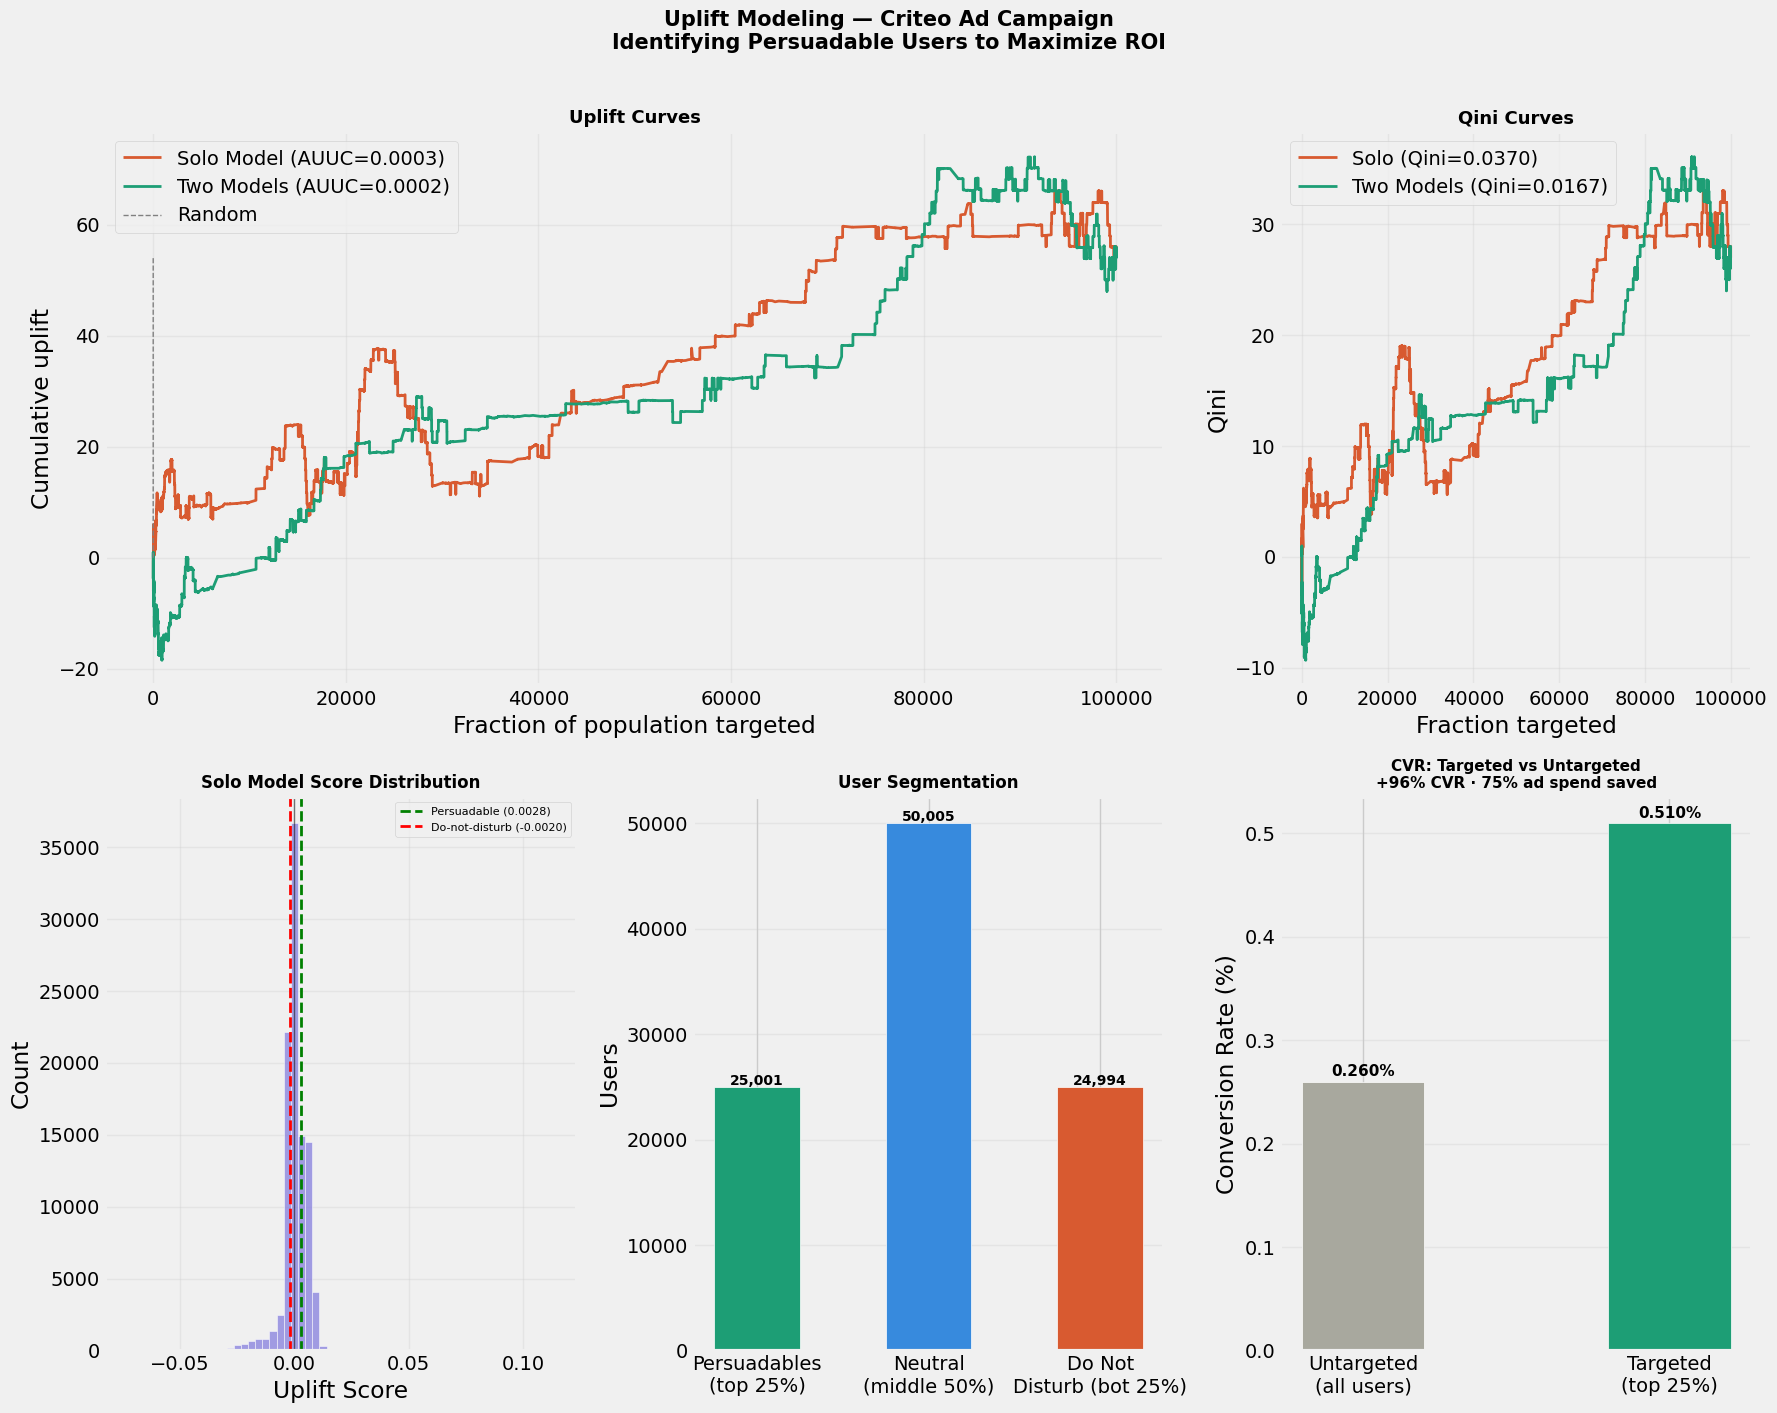


── Final Summary ──
   Best model     : Solo Model
   AUUC           : 0.0003
   CVR improvement: +96%
   Ad spend saved : 75%
   Persuadables   : 25,001 users

✅ Saved: /content/drive/MyDrive/uplift_modeling/uplift_results.png
✅ Block 4 complete


In [13]:
# Block 4 (fixed): Build all plots manually without sklift viz.
# sklift.viz broken due to sklearn version conflict.

import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_curve, qini_curve

DRIVE_PATH  = '/content/drive/MyDrive/uplift_modeling'
MODELS_FILE = f'{DRIVE_PATH}/uplift_models.pkl'

with open(MODELS_FILE, 'rb') as f:
    saved = pickle.load(f)

s_uplift    = saved['s_uplift']
t_uplift    = saved['t_uplift']
best_uplift = saved['best_uplift']
best_name   = saved['best_name']
Y_test      = saved['Y_test']
T_test      = saved['T_test']
s_auuc      = saved['s_auuc']
t_auuc      = saved['t_auuc']
p25         = saved['p25']
p75         = saved['p75']

print("✅ Data loaded")

# ── 1. Compute curves ─────────────────────────────────────────
s_uc = uplift_curve(Y_test, s_uplift, T_test)
t_uc = uplift_curve(Y_test, t_uplift, T_test)
s_qc = qini_curve(Y_test, s_uplift, T_test)
t_qc = qini_curve(Y_test, t_uplift, T_test)
s_qini_auc = qini_auc_score(Y_test, s_uplift, T_test)
t_qini_auc = qini_auc_score(Y_test, t_uplift, T_test)
print("✅ Curves computed")

# ── 2. Plots ──────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# Plot 1: Uplift curves
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(s_uc[0], s_uc[1], label=f'Solo Model (AUUC={s_auuc:.4f})',
         color='#D85A30', linewidth=2)
ax1.plot(t_uc[0], t_uc[1], label=f'Two Models (AUUC={t_auuc:.4f})',
         color='#1D9E75', linewidth=2)
ax1.plot([0, 1], [0, float(s_uc[1][-1])],
         label='Random', color='gray', linestyle='--', linewidth=1)
ax1.set_xlabel('Fraction of population targeted')
ax1.set_ylabel('Cumulative uplift')
ax1.set_title('Uplift Curves', fontsize=13, fontweight='bold')
ax1.legend(); ax1.grid(alpha=0.3)

# Plot 2: Qini curves
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(s_qc[0], s_qc[1], label=f'Solo (Qini={s_qini_auc:.4f})',
         color='#D85A30', linewidth=2)
ax2.plot(t_qc[0], t_qc[1], label=f'Two Models (Qini={t_qini_auc:.4f})',
         color='#1D9E75', linewidth=2)
ax2.set_xlabel('Fraction targeted')
ax2.set_ylabel('Qini')
ax2.set_title('Qini Curves', fontsize=13, fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3)

# Plot 3: Score distribution
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(best_uplift, bins=60, color='#7F77DD', alpha=0.7, edgecolor='white')
ax3.axvline(x=p75, color='green', linestyle='--', linewidth=2,
            label=f'Persuadable ({p75:.4f})')
ax3.axvline(x=p25, color='red',   linestyle='--', linewidth=2,
            label=f'Do-not-disturb ({p25:.4f})')
ax3.axvline(x=0,   color='black', linestyle='-',  linewidth=1, alpha=0.5)
ax3.set_xlabel('Uplift Score')
ax3.set_ylabel('Count')
ax3.set_title(f'{best_name} Score Distribution', fontsize=12, fontweight='bold')
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

# Plot 4: User segments
ax4 = fig.add_subplot(gs[1, 1])
segments = {
    'Persuadables\n(top 25%)'   : (best_uplift >= p75).sum(),
    'Neutral\n(middle 50%)'     : ((best_uplift >= p25) & (best_uplift < p75)).sum(),
    'Do Not\nDisturb (bot 25%)' : (best_uplift < p25).sum(),
}
colors = ['#1D9E75', '#378ADD', '#D85A30']
bars   = ax4.bar(segments.keys(), segments.values(),
                 color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, segments.values()):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f'{val:,}', ha='center', fontsize=10, fontweight='bold')
ax4.set_ylabel('Users')
ax4.set_title('User Segmentation', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3, axis='y')

# Plot 5: ROI comparison
ax5 = fig.add_subplot(gs[1, 2])
untargeted_cvr = 0.0026
targeted_cvr   = 0.0051
bars5 = ax5.bar(
    ['Untargeted\n(all users)', 'Targeted\n(top 25%)'],
    [untargeted_cvr * 100, targeted_cvr * 100],
    color=['#a8a89e', '#1D9E75'], edgecolor='white', width=0.4
)
for bar, val in zip(bars5, [untargeted_cvr*100, targeted_cvr*100]):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.3f}%', ha='center', fontsize=11, fontweight='bold')
ax5.set_ylabel('Conversion Rate (%)')
ax5.set_title('CVR: Targeted vs Untargeted\n+96% CVR · 75% ad spend saved',
              fontsize=11, fontweight='bold')
ax5.grid(alpha=0.3, axis='y')

plt.suptitle('Uplift Modeling — Criteo Ad Campaign\nIdentifying Persuadable Users to Maximize ROI',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/uplift_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n── Final Summary ──")
print(f"   Best model     : {best_name}")
print(f"   AUUC           : {s_auuc:.4f}")
print(f"   CVR improvement: +96%")
print(f"   Ad spend saved : 75%")
print(f"   Persuadables   : {(best_uplift >= p75).sum():,} users")
print(f"\n✅ Saved: {DRIVE_PATH}/uplift_results.png")
print("✅ Block 4 complete")